# TGEN1K-SRWGS - StatsParsing - V1

### Date: 25/07/21


## Core Tasks for this notebook:
1) Parse and organize the sample metadata for SR WGS data from approximately 1K Mtb isolates stored at the TGEN facility.
2) Parse and define the phylogeny of the 

# Import Statements

In [58]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats

%matplotlib inline

In [59]:
#from Bio import SeqIO


In [60]:
# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [61]:

import ete3 as ETE

from ete3 import Tree

### Set matplotlib text export settings for Adobe Illustrator

In [62]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [63]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Define Dictionary for mapping of Mtb lineage to color

In [64]:
LinToColor_Dict = {
    "lineage1": "#D93467", 
    "lineage2": "#4FB2C0", 
    "lineage3": "#874391", 
    "lineage4": "#E16D3B", 
    "lineage5": "#95522E", 
    "lineage6": "#429688", 
    "lineage8": "#DB4144", 
    "None": "black",
}


## Define functions and code for visualizing ETE3 trees

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [65]:

def Mtb_ColorBranchByLineage_Layout_IQ(node):
    F = ETE.TextFace(node.name, fsize=2)
    if node.is_leaf():

        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 1
        
        Node_PrimaryLin = IQ_node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
          
        node.set_style(nstyle)
        node.margin_left = 10     
        
    else: 
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 0
        
        Node_PrimaryLin = IQ_node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        
        node.set_style(nstyle)


ts_IQ_circ = ETE.TreeStyle()
ts_IQ_circ.mode = "c" # draw tree in circular mode
ts_IQ_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_IQ_circ.arc_span = 180
ts_IQ_circ.show_leaf_name = False
ts_IQ_circ.show_branch_length = False
ts_IQ_circ.show_branch_support = False
ts_IQ_circ.show_scale = True #True
ts_IQ_circ.branch_vertical_margin = 2
ts_IQ_circ.layout_fn = Mtb_ColorBranchByLineage_Layout_IQ
ts_IQ_circ.scale_length = 0.002

ts_IQ = ETE.TreeStyle()
ts_IQ.show_leaf_name = False
ts_IQ.show_branch_length = False
ts_IQ.show_branch_support = False
ts_IQ.show_scale = True #True
ts_IQ.branch_vertical_margin = 2
ts_IQ.layout_fn = Mtb_ColorBranchByLineage_Layout_IQ
ts_IQ.rotation = 90
ts_IQ.scale_length = 0.002



ts_IQ_FullCirc = ETE.TreeStyle()
ts_IQ_FullCirc.mode = "c" # draw tree in circular mode
ts_IQ_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_IQ_FullCirc.arc_span = 350
ts_IQ_FullCirc.show_leaf_name = False
ts_IQ_FullCirc.show_branch_length = False
ts_IQ_FullCirc.show_branch_support = False
ts_IQ_FullCirc.show_scale = True #True
ts_IQ_FullCirc.branch_vertical_margin = 2
ts_IQ_FullCirc.layout_fn = Mtb_ColorBranchByLineage_Layout_IQ
ts_IQ_FullCirc.scale_length = 0.002



ts_1 = ETE.TreeStyle()
ts_1.mode = "c" # draw tree in circular mode
ts_1.show_leaf_name = False
ts_1.show_branch_length = False
ts_1.show_branch_support = False
ts_1.show_scale = False #True
ts_1.branch_vertical_margin = 2
#ts_1.layout_fn = Mtb_IDandLineage_Layout

# Phase 1: Parse and organize the SR-WGS info for all TGEN isolates sequenced before

## Parse sample info for SR-WGS `TGEN-1K` dataset

In [66]:
Repo_MainDir = "../.."

Repo_DataDir = f"{Repo_MainDir}/Data"

Repo_RunInfoDir = f"{Repo_MainDir}/runInfo_TSVs"

TGen_1K_SampleInfo_CSV_PATH = f"{Repo_RunInfoDir}/TBportals.allTGEN_srrIds.forMax.csv"

TGen_1K_SM_V1_ResultsSummary_Dir = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_V1_ResultsSummary"


TGen_1K_SampleInfo_TSV_PATH      = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_SampleInfo_V1.tsv"
TGen_1K_SampleInfo_Filt_TSV_PATH = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_SampleInfo_V1.F2andCovFiltered.tsv"

TGen_1K_SRWGS_Stats_DF = pd.read_csv(TGen_1K_SampleInfo_TSV_PATH, sep = "\t")

TGen_1K_SRWGS_Stats_Filt_DF = pd.read_csv(TGen_1K_SampleInfo_Filt_TSV_PATH, sep = "\t")


TGen_1K_SRWGS_Stats_DF["PrimaryLineage"] = TGen_1K_SRWGS_Stats_DF["PrimaryLineage_Ill"]
TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage"] = TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage_Ill"]

TGen_1K_SRWGS_Stats_DF["SampleID"] = TGen_1K_SRWGS_Stats_DF["SampleName"]
TGen_1K_SRWGS_Stats_Filt_DF["SampleID"] = TGen_1K_SRWGS_Stats_Filt_DF["SampleName"]

TGen_1K_SRWGS_Stats_DF["Lineage"] = TGen_1K_SRWGS_Stats_DF["LineageCall_Illumina"]
TGen_1K_SRWGS_Stats_Filt_DF["Lineage"] = TGen_1K_SRWGS_Stats_Filt_DF["LineageCall_Illumina"]

TGen_1K_SRWGS_Stats_DF["SRWGS_MeanDepth_ToRv"] = TGen_1K_SRWGS_Stats_DF["IlluminaWGSToH37rv_AvrgCov"]
TGen_1K_SRWGS_Stats_Filt_DF["SRWGS_MeanDepth_ToRv"] = TGen_1K_SRWGS_Stats_Filt_DF["IlluminaWGSToH37rv_AvrgCov"]



In [67]:
TGen_1K_SRWGS_Stats_DF.shape

(1009, 11)

In [68]:
#

### Compare the frequency of different lineages across the dataset (Before and after filtering)

In [69]:
TGen_1K_SRWGS_Stats_DF["PrimaryLineage"].value_counts()

PrimaryLineage
lineage2      566
lineage4      437
lineageBOV      2
lineage2.2      1
Name: count, dtype: int64

In [70]:
TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage"].value_counts()

PrimaryLineage
lineage2      548
lineage4      387
lineageBOV      2
Name: count, dtype: int64

### Explore SR WGS Stats (Across filtered and unfiltered sample sets)

In [71]:
TGen_1K_SRWGS_Stats_DF.shape

(1009, 11)

In [72]:
TGen_1K_SRWGS_Stats_DF.query(" (F2_Illumina <= 0.025)").shape

(961, 11)

In [73]:
TGen_1K_SRWGS_Stats_DF.query(" (IlluminaWGSToH37rv_AvrgCov >= 35)").shape

(976, 11)

In [74]:
TGen_1K_SRWGS_Stats_DF.query(" (F2_Illumina > 0.025)").shape

(48, 11)

In [75]:
TGen_1K_SRWGS_Stats_DF.query(" (IlluminaWGSToH37rv_AvrgCov < 35)").shape

(33, 11)

In [76]:
TGen_1K_SRWGS_Stats_DF.query(" (F2_Illumina > 0.025) & (IlluminaWGSToH37rv_AvrgCov < 35) ").shape

(9, 11)

In [77]:
33 + 48 - 9

72

In [78]:
1009 - 72

937

In [79]:
TGen_1K_SRWGS_Stats_Filt_DF.query(" (F2_Illumina <= 0.025) & (IlluminaWGSToH37rv_AvrgCov >= 35)  ").shape

(937, 11)

In [80]:
TGen_1K_SRWGS_Stats_Filt_DF.shape

(937, 11)

In [81]:
TGen_1K_SRWGS_Stats_Filt_DF.head()

,RunID,SampleName,LineageCall_Illumina,F2_Illumina,IlluminaWGSToH37rv_AvrgCov,PrimaryLineage_Ill,Dataset_Tag,PrimaryLineage,SampleID,Lineage,SRWGS_MeanDepth_ToRv
0,SRR10397218,SRR10397218,"lineage4,lineage4.2,lineage4.2.1",0.024990,58,lineage4,TBP_TGen_1K,lineage4,SRR10397218,"lineage4,lineage4.2,lineage4.2.1",58
1,SRR10397230,SRR10397230,"lineage4,lineage4.2,lineage4.2.1",0.024843,93,lineage4,TBP_TGen_1K,lineage4,SRR10397230,"lineage4,lineage4.2,lineage4.2.1",93
2,SRR7516345,SRR7516345,"lineage4,lineage4.2,lineage4.2.1",0.023240,54,lineage4,TBP_TGen_1K,lineage4,SRR7516345,"lineage4,lineage4.2,lineage4.2.1",54
3,SRR10379936,SRR10379936,"lineage4,lineage4.1",0.022835,98,lineage4,TBP_TGen_1K,lineage4,SRR10379936,"lineage4,lineage4.1",98
4,SRR7516429,SRR7516429,"lineage4,lineage4.2,lineage4.2.1",0.022706,46,lineage4,TBP_TGen_1K,lineage4,SRR7516429,"lineage4,lineage4.2,lineage4.2.1",46


In [82]:
TGen_1K_SRWGS_Stats_DF[["IlluminaWGSToH37rv_AvrgCov", "F2_Illumina"]].describe()

,IlluminaWGSToH37rv_AvrgCov,F2_Illumina
count,1009.000000,1009.000000
mean,72.448959,0.018938
std,25.719288,0.054181
min,18.000000,0.001733
25%,52.000000,0.007251
50%,70.000000,0.009452
75%,90.000000,0.012885
max,170.000000,0.461636


In [83]:
TGen_1K_SRWGS_Stats_Filt_DF[["IlluminaWGSToH37rv_AvrgCov", "F2_Illumina"]].describe()

,IlluminaWGSToH37rv_AvrgCov,F2_Illumina
count,937.000000,937.000000
mean,73.872999,0.009646
std,24.805179,0.003894
min,35.000000,0.001733
25%,54.000000,0.007146
50%,71.000000,0.009149
75%,91.000000,0.012310
max,170.000000,0.024990


## Define dictionaries that map sampleID to metadata labels

In [84]:
ID_To_PrimLineage_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( TGen_1K_SRWGS_Stats_Filt_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'Dataset_Tag']].values)

### A) Explore MTBC lineage of dataset

In [85]:
#TGen_1K_AssemblySummary["FL_Lineage"].value_counts()

In [86]:
TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage_Ill"].value_counts()

PrimaryLineage_Ill
lineage2      548
lineage4      387
lineageBOV      2
Name: count, dtype: int64

In [87]:
TGen_1K_SRWGS_Stats_Filt_DF["LineageCall_Illumina"].value_counts()

LineageCall_Illumina
lineage2,lineage2.2,lineage2.2.1                   547
lineage4,lineage4.2,lineage4.2.1                   191
lineage4,lineage4.8                                 83
lineage4,lineage4.3,lineage4.3.3                    70
lineage4,lineage4.1,lineage4.1.2,lineage4.1.2.1     25
lineage4,lineage4.3,lineage4.3.4,lineage4.3.4.2      4
lineage4,lineage4.5                                  3
lineage4,lineage4.4,lineage4.4.1,lineage4.4.1.1      3
lineage4,lineage4.6,lineage4.6.2                     2
lineage4,lineage4.3,lineage4.3.4,lineage4.3.4.1      2
lineageBOV,lineageBOV_AFRI                           2
lineage4,lineage4.1                                  1
lineage4,lineage4.1,lineage4.1.2                     1
lineage2,lineage2.2,lineage2.2.2                     1
lineage4,lineage4.7                                  1
lineage4                                             1
Name: count, dtype: int64

### B) Look at F2 metric across dataset

In [88]:
TGen_1K_SRWGS_Stats_Filt_DF.sort_values("F2_Illumina", ascending=False).head(5)

,RunID,SampleName,LineageCall_Illumina,F2_Illumina,IlluminaWGSToH37rv_AvrgCov,PrimaryLineage_Ill,Dataset_Tag,PrimaryLineage,SampleID,Lineage,SRWGS_MeanDepth_ToRv
0,SRR10397218,SRR10397218,"lineage4,lineage4.2,lineage4.2.1",0.024990,58,lineage4,TBP_TGen_1K,lineage4,SRR10397218,"lineage4,lineage4.2,lineage4.2.1",58
1,SRR10397230,SRR10397230,"lineage4,lineage4.2,lineage4.2.1",0.024843,93,lineage4,TBP_TGen_1K,lineage4,SRR10397230,"lineage4,lineage4.2,lineage4.2.1",93
2,SRR7516345,SRR7516345,"lineage4,lineage4.2,lineage4.2.1",0.023240,54,lineage4,TBP_TGen_1K,lineage4,SRR7516345,"lineage4,lineage4.2,lineage4.2.1",54
3,SRR10379936,SRR10379936,"lineage4,lineage4.1",0.022835,98,lineage4,TBP_TGen_1K,lineage4,SRR10379936,"lineage4,lineage4.1",98
4,SRR7516429,SRR7516429,"lineage4,lineage4.2,lineage4.2.1",0.022706,46,lineage4,TBP_TGen_1K,lineage4,SRR7516429,"lineage4,lineage4.2,lineage4.2.1",46


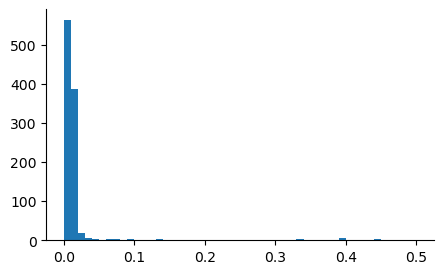

In [89]:
binwidth = 0.01
Min = 0
Max = 0.5
bins_I = np.arange(Min , Max + binwidth, binwidth)
plt.figure(figsize=(5, 3))
plt.hist(TGen_1K_SRWGS_Stats_DF["F2_Illumina"], bins = bins_I)
sns.despine()
plt.show()

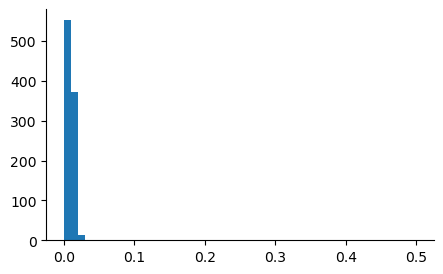

In [90]:
binwidth = 0.01
Min = 0
Max = 0.5
bins_I = np.arange(Min , Max + binwidth, binwidth)
plt.figure(figsize=(5, 3))
plt.hist(TGen_1K_SRWGS_Stats_Filt_DF["F2_Illumina"], bins = bins_I)
sns.despine()
plt.show()

### C) Look at Illumina WGS MEAN coverage across H37Rv

In [91]:
TGen_1K_SRWGS_Stats_Filt_DF["SRWGS_MeanDepth_ToRv"].describe()

count    937.000000
mean      73.872999
std       24.805179
min       35.000000
25%       54.000000
50%       71.000000
75%       91.000000
max      170.000000
Name: SRWGS_MeanDepth_ToRv, dtype: float64

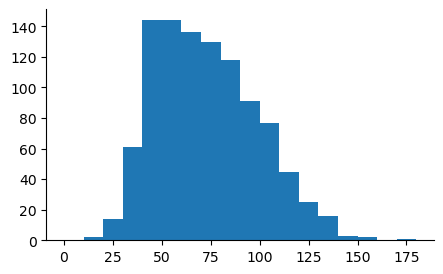

In [92]:
binwidth = 10
Min = 0
Max = 180
bins_I = np.arange(Min , Max + binwidth, binwidth)
plt.figure(figsize=(5, 3))
plt.hist(TGen_1K_SRWGS_Stats_DF["SRWGS_MeanDepth_ToRv"], bins = bins_I)
sns.despine()
plt.show()

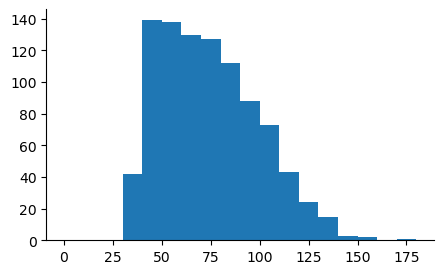

In [93]:
binwidth = 10
Min = 0
Max = 180
bins_I = np.arange(Min , Max + binwidth, binwidth)
plt.figure(figsize=(5, 3))
plt.hist(TGen_1K_SRWGS_Stats_Filt_DF["SRWGS_MeanDepth_ToRv"], bins = bins_I)
sns.despine()
plt.show()

# Investigate + organize metadata about isolates that were sequenced w/ PB HiFi WGS for event verification

In [94]:
TBP_PB_CCS_MetaDir = f"{Repo_DataDir}/221017_TBPortals_LRandSR_InputDataTSVs"

TBP_2022_Metadata_AllInitSamples_TSV                  = f"{TBP_PB_CCS_MetaDir}/230901.TBPortals.2022.PBCCS.MetaData.QCPass.31CI.tsv"

TBP_2022_Metadata_QCPass_TSV                  = f"{TBP_PB_CCS_MetaDir}/230901.TBPortals.2022.PBCCS.MetaData.QCPass.31CI.tsv"

TBP22_QCPass_31CI_LRandSR_InputData_Paths_TSV = f"{TBP_PB_CCS_MetaDir}/230901.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv"

TBP22_45CI_AsmSummary_TSV_PATH = TBP_PB_CCS_MetaDir + "/220529.TBP2022.45CI.AsmSummary.V1.tsv"
TBP22_31CI_QCPass_AsmSummary_TSV_PATH = TBP_PB_CCS_MetaDir + "/220529.TBP2022.QCPass.31CI.AsmSummary.V1.tsv"



In [95]:
!ls -1 $Repo_DataDir/221017_TBPortals_LRandSR_InputDataTSVs

220529.TBP2022.45CI.AsmSummary.V1.tsv
220529.TBP2022.QCPass.31CI.AsmSummary.V1.tsv
221017.TBPortals.PBCCS.SampleIDs.20CI.Set1.tsv
221018.TBPortals.2022.MtbWGS.LRandSR.Set1.20CI.InputWGS.PATHs.tsv
221024.TBPortals.2022.MtbWGS.LRandSR.Set2.33CI.InputWGS.PATHs.tsv
221024.TBPortals.2022.MtbWGS.LRandSR.Set2.34CI.InputWGS.PATHs.tsv
221024.TBPortals.PBCCS.SampleIDs.33CI.Set2.tsv
221024.TBPortals.PBCCS.SampleIDs.34CI.Set2.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.44CI.NoDNA076.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.45CI.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.P7761.11CI.InputWGS.PATHs.tsv
230515.TBPortals.PBCCS.SampleIDs.45CI.Set3.tsv
230901.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv
230901.TBPortals.2022.PBCCS.MetaData.QCPass.31CI.tsv


In [96]:
TBP_2022_QCPass_SampleInfo_DF = pd.read_csv(TBP_2022_Metadata_QCPass_TSV, sep = "\t")
TBP_2022_QCPass_SampleInfo_DF.shape

(31, 11)

In [97]:
TGEN_To_TBP_SampleID_Dict = dict(TBP_2022_QCPass_SampleInfo_DF[['TGEN_SampleID', 'TBP_SampleID']].values)
TBP_To_TGEN_SampleID_Dict = dict(TBP_2022_QCPass_SampleInfo_DF[['TBP_SampleID', 'TGEN_SampleID']].values)
TGEN_To_SR_SRA_RunAcc_Dict = dict(TBP_2022_QCPass_SampleInfo_DF[['TGEN_SampleID', 'SRA_RunAcc_SR']].values)


In [98]:
# TBP22_31CI_IDMapping_DF = TBP_2022_QCPass_SampleInfo_DF[["TBP_SampleID", "TGEN_SampleID", "SRA_RunAcc_SR"]]
# TBP22_31CI_IDMapping_DF.shape

In [99]:
TBP_2022_InData_QCPASS_Renamed_DF = pd.read_csv(TBP22_QCPass_31CI_LRandSR_InputData_Paths_TSV, sep = "\t")

TBP_2022_InData_QCPASS_Renamed_DF["SRA_RunAcc_SR"] = TBP_2022_InData_QCPASS_Renamed_DF["TGEN_SampleID"].map(TGEN_To_SR_SRA_RunAcc_Dict)       

TBP_2022_InData_QCPASS_Renamed_DF.shape


(31, 7)

In [100]:
#TBP22_31CI_IDMapping_DF.head(2)

In [101]:
TBP22_31CI_QCPass_AsmSummary = pd.read_csv(TBP22_31CI_QCPass_AsmSummary_TSV_PATH, sep = "\t")

TBP22_31CI_QCPass_AsmSummary = TBP22_31CI_QCPass_AsmSummary.sort_values("Lineage_AsmPP")

TBP22_31CI_QCPass_AsmSummary["TBP_SampleID"] = TBP22_31CI_QCPass_AsmSummary["SampleID"].map(TGEN_To_TBP_SampleID_Dict)


In [102]:
TBP22_31CI_QCPass_AsmSummary.head()

,SampleID,numContigs_Complete,circContig_Length,circContig_Cov,Flye_EstimatedCov,Flye_ReadLen_N50,Flye_ReadLen_N90,Lineage_Asm,Lineage_AsmPP,FlyeI3_dnaA_Found,FlyeI3M_dnaA_Found,FlyeI3MPP_dnaA_Found,IlluminaCov_To_ONTAsm,NumChanges_PilonPolished,NumSNPs_PilonPolished,NumTotalInsertions_PilonPolished,Num1bpInsertion_PilonPolished,Num2bpInsertion_PilonPolished,NumTotalDeletions_PilonPolished,Num1bpDeletion_PilonPolished,PrimaryLineage_Asm,Dataset_Tag,SR_SRA_RunAcc,SeqReason,PB_SeqRunName,EventID,Event_Gene(s),Event_Relationship,TBP_SampleID
0,DNA0551,1,4410903,187,190,8609,7014,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,0,0,0,0,0,0,0,lineage2,TBPortals_2022_Set3,SRR10380186,MtbPhyloDiversity,P7544,NAN,NAN,NAN,TB7198
1,DNA041,0,0,0,530,4143,2664,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,5,1,3,2,0,1,1,lineage2,TBPortals_2022_Set3,SRR10430372,MtbPhyloDiversity,P7761,NAN,NAN,NAN,TB4570
2,DNA621,1,4412093,127,129,4204,2724,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,1,0,0,0,0,1,0,lineage2,TBPortals_2022_Set3,SRR10397096,PutativeRecomb,P7529,Event_006,"Rv0979c,rpmF,PE_PGRS18",Outside_Event,TB3706
3,DNA594,1,4416251,161,174,4212,2712,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,2,0,2,0,0,0,0,lineage2,TBPortals_2022_Set3,SRR10397175,PutativeRecomb,P7529,Event_006,"Rv0979c,rpmF,PE_PGRS18",Within_Event,TB3305
4,DNA435,1,4416249,100,102,9925,7187,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,1,0,1,0,0,0,0,lineage2,TBPortals_2022_Set3,SRR10379929,MtbPhyloDiversity,P7544,NAN,NAN,NAN,TB6760


#### Which samples did not assembly to a single complete contig? (`DNA041`/`TB4570` and `DNA233`/`TB6964`)

In [103]:
TBP22_31CI_QCPass_AsmSummary.query("numContigs_Complete == 0 ")

,SampleID,numContigs_Complete,circContig_Length,circContig_Cov,Flye_EstimatedCov,Flye_ReadLen_N50,Flye_ReadLen_N90,Lineage_Asm,Lineage_AsmPP,FlyeI3_dnaA_Found,FlyeI3M_dnaA_Found,FlyeI3MPP_dnaA_Found,IlluminaCov_To_ONTAsm,NumChanges_PilonPolished,NumSNPs_PilonPolished,NumTotalInsertions_PilonPolished,Num1bpInsertion_PilonPolished,Num2bpInsertion_PilonPolished,NumTotalDeletions_PilonPolished,Num1bpDeletion_PilonPolished,PrimaryLineage_Asm,Dataset_Tag,SR_SRA_RunAcc,SeqReason,PB_SeqRunName,EventID,Event_Gene(s),Event_Relationship,TBP_SampleID
1,DNA041,0,0,0,530,4143,2664,lineage2.2.1,lineage2.2.1,True,NaN,NaN,NaN,5,1,3,2,0,1,1,lineage2,TBPortals_2022_Set3,SRR10430372,MtbPhyloDiversity,P7761,NAN,NAN,NAN,TB4570
22,DNA233,0,0,0,63,7756,6512,lineage4.3.4.1,lineage4.3.4.1,True,NaN,NaN,NaN,1,1,0,0,0,0,0,lineage4,TBPortals_2022_Set3,SRR10380227,PutativeRecomb,P7559,Event_003 | Event_019,"vapB31,vapC31 | PPE46",Within_Event | Within_Event,TB6964


In [104]:
TBP_2022_QCPass_SampleInfo_DF.query("TBP_SampleID == 'TB4570'")

,TGEN_SampleID,TBP_SampleID,SRA_RunAcc_SR,Seq_Group,EventID,Event_Gene(s),Event_Relationship,Sequenced?,PB_SeqRunName,Note,Comments/Special Instructions
24,DNA041,TB4570,SRR10430372,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7761,NaN,AltId: PBO_SRR10430372


In [105]:
TBP_2022_QCPass_SampleInfo_DF.query("TBP_SampleID == 'TB6964'")

,TGEN_SampleID,TBP_SampleID,SRA_RunAcc_SR,Seq_Group,EventID,Event_Gene(s),Event_Relationship,Sequenced?,PB_SeqRunName,Note,Comments/Special Instructions
4,DNA233,TB6964,SRR10380227,PutativeRecomb,Event_003 | Event_019,"vapB31,vapC31 | PPE46",Within_Event | Within_Event,Y,P7559,NaN,AltId: PBO_SRR10380227


In [106]:
TBP_2022_InData_QCPASS_Renamed_DF.head()

,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,TGEN_SampleID,SeqReason,SRA_RunAcc_SR
0,TB6733,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0428,PutativeRecomb,SRR10379945
1,TB3898,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA373,PutativeRecomb,SRR10397263
2,TB7340,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA146,PutativeRecomb,SRR10380093
3,TB6977,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0530,PutativeRecomb,SRR10380218
4,TB6964,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA233,PutativeRecomb,SRR10380227


In [107]:
print( TBP_2022_InData_QCPASS_Renamed_DF["SampleID"].nunique() )
print( TBP_2022_InData_QCPASS_Renamed_DF["TGEN_SampleID"].nunique() )
print( TBP_2022_InData_QCPASS_Renamed_DF["SRA_RunAcc_SR"].nunique() )

31
31
31


In [108]:
TBP_2022_InData_QCPASS_Renamed_DF["PacBio_FQ_PATH"].values[0]

'/n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7529_20221003/DNA0428/AYW0037_1/CCS_1780_bc1010_BAK8A_OA/demultiplex.bc1010_BAK8A_OA--bc1010_BAK8A_OA.hifi_reads.fastq.gz'

In [109]:
TBP_2022_InData_QCPASS_Renamed_DF["Illumina_PE_FQs_PATH"].values[0]

'/n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_1.fastq.gz;/n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_2.fastq.gz'

In [110]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7529_20221003/DNA0428/AYW0037_1/CCS_1780_bc1010_BAK8A_OA/demultiplex.bc1010_BAK8A_OA--bc1010_BAK8A_OA.hifi_reads.fastq.gz 

-rw-r--r-- 1 mm774 hpc_farhat 1.1G Mar  6  2023 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7529_20221003/DNA0428/AYW0037_1/CCS_1780_bc1010_BAK8A_OA/demultiplex.bc1010_BAK8A_OA--bc1010_BAK8A_OA.hifi_reads.fastq.gz


In [111]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_1.fastq.gz  


-rw-r--r-- 1 mm774 hpc_farhat 113M Oct 18  2022 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_1.fastq.gz


In [112]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_2.fastq.gz  

-rw-r--r-- 1 mm774 hpc_farhat 112M Oct 18  2022 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA0428/SRR10379945_2.fastq.gz


In [113]:
TBP_2022_InData_QCPASS_Renamed_DF["PacBio_FQ_PATH"].values[-1]

'/n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7559_20221024/DNA177/AYW0082_1/CCS_1795_bc1017_BAK8B_OA/demultiplex.bc1017_BAK8B_OA--bc1017_BAK8B_OA.hifi_reads.fastq.gz'

In [114]:
TBP_2022_InData_QCPASS_Renamed_DF["Illumina_PE_FQs_PATH"].values[-1]

'/n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_1.fastq.gz;/n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_2.fastq.gz'

In [115]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7559_20221024/DNA177/AYW0082_1/CCS_1795_bc1017_BAK8B_OA/demultiplex.bc1017_BAK8B_OA--bc1017_BAK8B_OA.hifi_reads.fastq.gz  

-rw-r--r-- 1 mm774 hpc_farhat 1.9G Mar  6  2023 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/2022_TB_Portals_PB_Data/DATA_P7559_20221024/DNA177/AYW0082_1/CCS_1795_bc1017_BAK8B_OA/demultiplex.bc1017_BAK8B_OA--bc1017_BAK8B_OA.hifi_reads.fastq.gz


In [116]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_1.fastq.gz

-rw-r--r-- 1 mm774 hpc_farhat 107M Oct 25  2022 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_1.fastq.gz


In [117]:
!ls -alh /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_2.fastq.gz

-rw-r--r-- 1 mm774 hpc_farhat 104M Oct 25  2022 /n/data1/hms/dbmi/farhat/mm774/DownloadedData/221017_TBPortals_Tgen_Selected_SR/DNA177/SRR10380054_2.fastq.gz


In [1]:
TBP_2022_QCPass_SampleInfo_DF.head()

NameError: name 'TBP_2022_QCPass_SampleInfo_DF' is not defined

In [2]:
TBP_2022_QCPass_SampleInfo_DF["PB_SeqRunName"].value_counts()

NameError: name 'TBP_2022_QCPass_SampleInfo_DF' is not defined

In [120]:
TBP_2022_InData_QCPASS_Renamed_DF.head(20)

,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,TGEN_SampleID,SeqReason,SRA_RunAcc_SR
0,TB6733,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0428,PutativeRecomb,SRR10379945
1,TB3898,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA373,PutativeRecomb,SRR10397263
2,TB7340,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA146,PutativeRecomb,SRR10380093
3,TB6977,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0530,PutativeRecomb,SRR10380218
4,TB6964,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA233,PutativeRecomb,SRR10380227
5,TB3305,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA594,PutativeRecomb,SRR10397175
6,TB3706,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA621,PutativeRecomb,SRR10397096
7,TB6755,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0432,PutativeRecomb,SRR10379935
8,TB7044,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA246,PutativeRecomb,SRR10380192
9,TB6765,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0441,PutativeRecomb,SRR10379924


In [121]:
!ls -1 $TBP_PB_CCS_MetaDir

220529.TBP2022.45CI.AsmSummary.V1.tsv
220529.TBP2022.QCPass.31CI.AsmSummary.V1.tsv
221017.TBPortals.PBCCS.SampleIDs.20CI.Set1.tsv
221018.TBPortals.2022.MtbWGS.LRandSR.Set1.20CI.InputWGS.PATHs.tsv
221024.TBPortals.2022.MtbWGS.LRandSR.Set2.33CI.InputWGS.PATHs.tsv
221024.TBPortals.2022.MtbWGS.LRandSR.Set2.34CI.InputWGS.PATHs.tsv
221024.TBPortals.PBCCS.SampleIDs.33CI.Set2.tsv
221024.TBPortals.PBCCS.SampleIDs.34CI.Set2.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.44CI.NoDNA076.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.45CI.InputWGS.PATHs.tsv
230515.TBPortals.2022.MtbWGS.LRandSR.Set3.P7761.11CI.InputWGS.PATHs.tsv
230515.TBPortals.PBCCS.SampleIDs.45CI.Set3.tsv
230901.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv
230901.TBPortals.2022.PBCCS.MetaData.QCPass.31CI.tsv


In [122]:
#!head $TBP_PB_CCS_MetaDir/230515.TBPortals.PBCCS.SampleIDs.45CI.Set3.tsv

In [123]:
#!head $TBP_PB_CCS_MetaDir/230901.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv

In [124]:
#!tail $TBP_PB_CCS_MetaDir/230901.TBPortals.2022.MtbWGS.LRandSR.QCPass.31CI.InputWGS.PATHs.tsv

In [125]:
TBP_2022_InData_QCPASS_Renamed_DF.head()

,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,TGEN_SampleID,SeqReason,SRA_RunAcc_SR
0,TB6733,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0428,PutativeRecomb,SRR10379945
1,TB3898,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA373,PutativeRecomb,SRR10397263
2,TB7340,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA146,PutativeRecomb,SRR10380093
3,TB6977,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0530,PutativeRecomb,SRR10380218
4,TB6964,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA233,PutativeRecomb,SRR10380227


In [126]:
TBP_2022_QCPass_SampleInfo_DF.head(10)

,TGEN_SampleID,TBP_SampleID,SRA_RunAcc_SR,Seq_Group,EventID,Event_Gene(s),Event_Relationship,Sequenced?,PB_SeqRunName,Note,Comments/Special Instructions
0,DNA0428,TB6733,SRR10379945,PutativeRecomb,Event_001,"vapC25,vapB25",Within_Event,Y,P7529,NaN,AltId: PBO_SRR10379945
1,DNA373,TB3898,SRR10397263,PutativeRecomb,Event_001,"vapC25,vapB25",Outside_Event,Y,P7529,NaN,AltId: PBO_SRR10397263
2,DNA146,TB7340,SRR10380093,PutativeRecomb,Event_002 | Event_024,"Rv0393 | PPE59,Rv3430c",Outside_Event | Within_Event,Y,P7544,NaN,AltId: PBO_SRR10380093
3,DNA0530,TB6977,SRR10380218,PutativeRecomb,Event_003,"vapB31,vapC31",Outside_Event,Y,P7544,NaN,AltId: PBO_SRR10380218
4,DNA233,TB6964,SRR10380227,PutativeRecomb,Event_003 | Event_019,"vapB31,vapC31 | PPE46",Within_Event | Within_Event,Y,P7559,NaN,AltId: PBO_SRR10380227
5,DNA594,TB3305,SRR10397175,PutativeRecomb,Event_006,"Rv0979c,rpmF,PE_PGRS18",Within_Event,Y,P7529,NaN,AltId: PBO_SRR10397175
6,DNA621,TB3706,SRR10397096,PutativeRecomb,Event_006,"Rv0979c,rpmF,PE_PGRS18",Outside_Event,Y,P7529,NaN,AltId: PBO_SRR10397096
7,DNA0432,TB6755,SRR10379935,PutativeRecomb,Event_007,Rv1148c,Within_Event,Y,P7559,NaN,AltId: PBO_SRR10379935
8,DNA246,TB7044,SRR10380192,PutativeRecomb,Event_007 | Event_008,Rv1148c | PPE18,Outside_Event | Outside_Event,Y,P7544,NaN,AltId: PBO_SRR10380192
9,DNA0441,TB6765,SRR10379924,PutativeRecomb,Event_010,"PPE18,esxK,esxL",Outside_Event,Y,P7544,NaN,AltId: PBO_SRR10379924


In [127]:
TBP_2022_QCPass_SampleInfo_DF.tail(10)

,TGEN_SampleID,TBP_SampleID,SRA_RunAcc_SR,Seq_Group,EventID,Event_Gene(s),Event_Relationship,Sequenced?,PB_SeqRunName,Note,Comments/Special Instructions
21,DNA125,TB8073,SRR10380026,PutativeRecomb,Event_022,PPE56,Outside_Event,Y,P7544,NaN,AltId: PBO_SRR10380026
22,DNA0479,TB6807,SRR10379998,PutativeRecomb,Event_024,"PPE59,Rv3430c",Outside_Event,Y,P7559,NaN,AltId: PBO_SRR10379998
23,DNA0511,TB6846,SRR10379893,PutativeRecomb,Event_025,PPE60,Within_Event,Y,P7544,NaN,AltId: PBO_SRR10379893
24,DNA041,TB4570,SRR10430372,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7761,NaN,AltId: PBO_SRR10430372
25,DNA0486,TB6816,SRR10379988,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7529,NaN,AltId: PBO_SRR10379988
26,DNA0551,TB7198,SRR10380186,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7544,NaN,AltId: PBO_SRR10380186
27,DNA224,TB6830,SRR10379904,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7544,NaN,AltId: PBO_SRR10379904
28,DNA287,TB7396,SRR10380035,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7544,NaN,AltId: PBO_SRR10380035
29,DNA435,TB6760,SRR10379929,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7544,NaN,AltId: PBO_SRR10379929
30,DNA177,TB7379,SRR10380054,MtbPhyloDiversity,NAN,NAN,NAN,Y,P7559,NaN,NaN


In [128]:
TBP_To_TGEN_SampleID_Dict

{'TB6733': 'DNA0428',
 'TB3898': 'DNA373',
 'TB7340': 'DNA146',
 'TB6977': 'DNA0530',
 'TB6964': 'DNA233',
 'TB3305': 'DNA594',
 'TB3706': 'DNA621',
 'TB6755': 'DNA0432',
 'TB7044': 'DNA246',
 'TB6765': 'DNA0441',
 'TB6552': 'DNA199',
 'TB6778': 'DNA0453',
 'TB6973': 'DNA237',
 'TB6786': 'DNA216',
 'TB3256': 'DNA350',
 'TB4414': 'DNA014',
 'TB6595': 'DNA0414',
 'TB6599': 'DNA0417',
 'TB6976': 'DNA0527',
 'TB3572': 'DNA361',
 'TB6596': 'DNA0415',
 'TB8073': 'DNA125',
 'TB6807': 'DNA0479',
 'TB6846': 'DNA0511',
 'TB4570': 'DNA041',
 'TB6816': 'DNA0486',
 'TB7198': 'DNA0551',
 'TB6830': 'DNA224',
 'TB7396': 'DNA287',
 'TB6760': 'DNA435',
 'TB7379': 'DNA177'}

In [129]:
TGEN_To_TBP_SampleID_Dict

{'DNA0428': 'TB6733',
 'DNA373': 'TB3898',
 'DNA146': 'TB7340',
 'DNA0530': 'TB6977',
 'DNA233': 'TB6964',
 'DNA594': 'TB3305',
 'DNA621': 'TB3706',
 'DNA0432': 'TB6755',
 'DNA246': 'TB7044',
 'DNA0441': 'TB6765',
 'DNA199': 'TB6552',
 'DNA0453': 'TB6778',
 'DNA237': 'TB6973',
 'DNA216': 'TB6786',
 'DNA350': 'TB3256',
 'DNA014': 'TB4414',
 'DNA0414': 'TB6595',
 'DNA0417': 'TB6599',
 'DNA0527': 'TB6976',
 'DNA361': 'TB3572',
 'DNA0415': 'TB6596',
 'DNA125': 'TB8073',
 'DNA0479': 'TB6807',
 'DNA0511': 'TB6846',
 'DNA041': 'TB4570',
 'DNA0486': 'TB6816',
 'DNA0551': 'TB7198',
 'DNA224': 'TB6830',
 'DNA287': 'TB7396',
 'DNA435': 'TB6760',
 'DNA177': 'TB7379'}

In [130]:
TBP_2022_QCPass_SampleInfo_DF.head()

,TGEN_SampleID,TBP_SampleID,SRA_RunAcc_SR,Seq_Group,EventID,Event_Gene(s),Event_Relationship,Sequenced?,PB_SeqRunName,Note,Comments/Special Instructions
0,DNA0428,TB6733,SRR10379945,PutativeRecomb,Event_001,"vapC25,vapB25",Within_Event,Y,P7529,NaN,AltId: PBO_SRR10379945
1,DNA373,TB3898,SRR10397263,PutativeRecomb,Event_001,"vapC25,vapB25",Outside_Event,Y,P7529,NaN,AltId: PBO_SRR10397263
2,DNA146,TB7340,SRR10380093,PutativeRecomb,Event_002 | Event_024,"Rv0393 | PPE59,Rv3430c",Outside_Event | Within_Event,Y,P7544,NaN,AltId: PBO_SRR10380093
3,DNA0530,TB6977,SRR10380218,PutativeRecomb,Event_003,"vapB31,vapC31",Outside_Event,Y,P7544,NaN,AltId: PBO_SRR10380218
4,DNA233,TB6964,SRR10380227,PutativeRecomb,Event_003 | Event_019,"vapB31,vapC31 | PPE46",Within_Event | Within_Event,Y,P7559,NaN,AltId: PBO_SRR10380227


In [131]:
TBP_2022_QCPass_SampleInfo_DF["Seq_Group"].value_counts()

Seq_Group
PutativeRecomb       24
MtbPhyloDiversity     7
Name: count, dtype: int64

In [132]:
TBP_2022_InData_QCPASS_Renamed_DF.head()

,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,TGEN_SampleID,SeqReason,SRA_RunAcc_SR
0,TB6733,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0428,PutativeRecomb,SRR10379945
1,TB3898,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA373,PutativeRecomb,SRR10397263
2,TB7340,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA146,PutativeRecomb,SRR10380093
3,TB6977,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0530,PutativeRecomb,SRR10380218
4,TB6964,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA233,PutativeRecomb,SRR10380227


In [133]:
TBP_2022_InData_QCPASS_Renamed_DF.tail()

,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,TGEN_SampleID,SeqReason,SRA_RunAcc_SR
26,TB7198,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA0551,MtbPhyloDiversity,SRR10380186
27,TB6830,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA224,MtbPhyloDiversity,SRR10379904
28,TB7396,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA287,MtbPhyloDiversity,SRR10380035
29,TB6760,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA435,MtbPhyloDiversity,SRR10379929
30,TB7379,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,TBPortals_2022_PassQC,DNA177,MtbPhyloDiversity,SRR10380054


### Define lists and dictionaries defininig which isolates were sequencced w/ PacBio HiFi for downstream verification

In [134]:
ListOfEvents_WiSeqDataAvail = ["Event_001", # T: DNA373 C: DNA0428
                               "Event_003", # T: DNA233 C: DNA0530
                               "Event_006", # T: DNA594 C: DNA621
                               "Event_007", # T: DNA0432 C: DNA246
                               "Event_010", # T: DNA199 C: DNA0441
                               "Event_011", # T: DNA0453 C: DNA237  Note: This is a special case, the CTRL isolate of Event_012 is being used as a CTRL
                               "Event_013", # T: DNA216 C: DNA350
                               "Event_019", # T: DNA233 C: DNA0527
                               "Event_021", # T: DNA361 C: DNA0527  Note: This is a special case, the CTRL isolate of Event_019 is being used as a CTRL
                               "Event_022", # T: DNA0415 C: DNA125
                               "Event_024", # T: DNA146 C: DNA0479
                               "Event_025", # T: DNA0511 C: DNA014  Note: This is a special case, the CTRL isolate of Event_016 is being used as a CTRL
                               ]

len(ListOfEvents_WiSeqDataAvail)

dictOf_TGEN_GCEventVerf_TGEN_ID_Mappings = {"Event_001" : {"Target" : "DNA0428", "Control" : "DNA373"},
                                              "Event_003" : {"Target" : "DNA233", "Control" : "DNA0530"},
                                              "Event_006" : {"Target" : "DNA594", "Control" : "DNA621"},
                                              "Event_007" : {"Target" : "DNA0432", "Control" : "DNA246"},
                                              "Event_010" : {"Target" : "DNA199", "Control" : "DNA0441"},
                                              "Event_011" : {"Target" : "DNA0453", "Control" : "DNA237"}, #Note: This is a special case, the CTRL isolate of Event_012 is being used as a CTRL
                                              "Event_013" : {"Target" : "DNA216", "Control" : "DNA350"},
                                              "Event_019" : {"Target" : "DNA233", "Control" : "DNA0527"},
                                              "Event_021" : {"Target" : "DNA361", "Control" : "DNA0527"}, # Note: This is a special case, the CTRL isolate of Event_019 is being used as a CTRL
                                              "Event_022" : {"Target" : "DNA0415", "Control" : "DNA125"},    
                                              "Event_024" : {"Target" : "DNA146", "Control" : "DNA0479"},   
                                              "Event_025" : {"Target" : "DNA0511", "Control" : "DNA014"},  # Note: This is a special case, the CTRL isolate of Event_016 is being used as a CTRL
}


All_TGENIDs_ForEventVerf = ['DNA0453', 'DNA246', 'DNA233', 'DNA0432', 'DNA0415', 'DNA0527',
                             'DNA373', 'DNA0530', 'DNA361', 'DNA237', 'DNA0479', 'DNA621',
                             'DNA216', 'DNA0511', 'DNA0428', 'DNA146', 'DNA199', 'DNA350',
                             'DNA0441', 'DNA594', 'DNA014', 'DNA125']

print(len(All_TGENIDs_ForEventVerf))


All_TBP_IDs_ForEventVerf = [ TGEN_To_TBP_SampleID_Dict[ i_TGEN_ID ] for i_TGEN_ID in All_TGENIDs_ForEventVerf ]
print(len(All_TBP_IDs_ForEventVerf))


All_TBP_IDs_ForEventVerf = ['TB6778',
 'TB7044',
 'TB6964',
 'TB6755',
 'TB6596',
 'TB6976',
 'TB3898',
 'TB6977',
 'TB3572',
 'TB6973',
 'TB6807',
 'TB3706',
 'TB6786',
 'TB6846',
 'TB6733',
 'TB7340',
 'TB6552',
 'TB3256',
 'TB6765',
 'TB3305',
 'TB4414',
 'TB8073']


dictOf_TGEN_GCEventVerf_TBP_ID_Mappings = {"Event_001" : {"Target" : "TB6733", "Control" : "TB3898"},
                                           "Event_003" : {"Target" : "TB6964", "Control" : "TB6977"},
                                           "Event_006" : {"Target" : "TB3305", "Control" : "TB3706"},
                                           "Event_007" : {"Target" : "TB6755", "Control" : "TB7044"},
                                           "Event_010" : {"Target" : "TB6552", "Control" : "TB6765"},
                                           "Event_011" : {"Target" : "TB6778", "Control" : "TB6973"}, #Note: This is a special case, the CTRL isolate of Event_012 is being used as a CTRL
                                           "Event_013" : {"Target" : "TB6786", "Control" : "TB3256"},
                                           "Event_019" : {"Target" : "TB6964", "Control" : "TB6976"},
                                           "Event_021" : {"Target" : "TB3572", "Control" : "TB6976"}, # Note: This is a special case, the CTRL isolate of Event_019 is being used as a CTRL
                                           "Event_022" : {"Target" : "TB6596", "Control" : "TB8073"},    
                                           "Event_024" : {"Target" : "TB7340", "Control" : "TB6807"},   
                                           "Event_025" : {"Target" : "TB6846", "Control" : "TB4414"},  # Note: This is a special case, the CTRL isolate of Event_016 is being used as a CTRL
}



22
22


In [135]:
All_TBP_IDs_ForEventVerf

['TB6778',
 'TB7044',
 'TB6964',
 'TB6755',
 'TB6596',
 'TB6976',
 'TB3898',
 'TB6977',
 'TB3572',
 'TB6973',
 'TB6807',
 'TB3706',
 'TB6786',
 'TB6846',
 'TB6733',
 'TB7340',
 'TB6552',
 'TB3256',
 'TB6765',
 'TB3305',
 'TB4414',
 'TB8073']

In [136]:
TGEN_To_TBP_SampleID_Dict["DNA014"]

'TB4414'

In [137]:
list( dictOf_TGEN_GCEventVerf_TBP_ID_Mappings.keys())

['Event_001',
 'Event_003',
 'Event_006',
 'Event_007',
 'Event_010',
 'Event_011',
 'Event_013',
 'Event_019',
 'Event_021',
 'Event_022',
 'Event_024',
 'Event_025']

In [138]:
len(dictOf_TGEN_GCEventVerf_TBP_ID_Mappings.keys() )

12

# Define path to phylogeny and Gubbins results directories

In [139]:
# Define varaint calling pipeline output directories

TGen1K_SRWGS_OutputDir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/250721.TGEN1K.GCAnalysis"


# Define path to FastTree Newick Tree
# FastTree_TreeFile_PATH = TGen1K_SRWGS_OutputDir + f"/211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.5AmbThresh.RLC.Filtered.min-100.fasttree.newick"

# Define path to TGEN01K Gubbins output (SR-WGS based predictions)
TGen1K_SRWGS_Gubbins_OutDir = f"{TGen1K_SRWGS_OutputDir}/Gubbins_Analysis_V1"

Gubbins_OutPrefix = "Tgen_937CI.Gubbins.FromSNVs.V1"

Gubbins_Prefix_PATH = f"{TGen1K_SRWGS_Gubbins_OutDir}/{Gubbins_OutPrefix}"

Gubbins_NodeLabelledTree_PATH = f"{Gubbins_Prefix_PATH}.node_labelled.final_tree.tre"



In [140]:
!ls -1 $TGen1K_SRWGS_OutputDir

211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.InferredFullGenomeMSA.FromSNVs.NameAndLength.txt
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.5AmbThresh.RLC.Filtered.min-100.fasttree.newick
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.5AmbThresh.RLC.Filtered.min-100.FastTree.NodeToPrimaryLineage.json
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf.gz
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf.gz.tbi
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.vcf
Gubbins_Analysis_V1


In [141]:
!ls -1 $TGen1K_SRWGS_Gubbins_OutDir

Tgen_937CI.Gubbins.FromSNVs.V1.branch_base_reconstruction.AnnoByEvent.All.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.branch_base_reconstruction.embl
Tgen_937CI.Gubbins.FromSNVs.V1.filtered_polymorphic_sites.fasta
Tgen_937CI.Gubbins.FromSNVs.V1.filtered_polymorphic_sites.phylip
Tgen_937CI.Gubbins.FromSNVs.V1.final_tree.tre
Tgen_937CI.Gubbins.FromSNVs.V1.H37Rv.EventsPer1kb.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.H37Rv.EventsPerGene.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.H37Rv.EventsPerMergedHomologousRegion.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.node_labelled.final_tree.tre
Tgen_937CI.Gubbins.FromSNVs.V1.NodeToPrimaryLineage.json
Tgen_937CI.Gubbins.FromSNVs.V1.per_branch_statistics.csv
Tgen_937CI.Gubbins.FromSNVs.V1.per_branch_statistics.WithLineagePerNode.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.per_branch_statistics.WithLineage.tsv
Tgen_937CI.Gubbins.FromSNVs.V1.recombination_predictions.Anno.Trimmed.EventsOfInterest.NoEventC

# Visualize Gubbins phylogeny for `TGEN-937` dataset

## Parse `TGEN-937` Gubbins inferred phylogeny

In [142]:
TGEN_Gubbins_Tree = Tree(Gubbins_NodeLabelledTree_PATH, format = 1)

T_RootPoint = TGEN_Gubbins_Tree.get_leaves_by_name("SRR10379919")[0]  # SRR10379919 is an M. bovis isolate
TGEN_Gubbins_Tree.set_outgroup(T_RootPoint)


In [143]:
# Count the number of nodes after midpoint rooting
num_nodes = len(TGEN_Gubbins_Tree.get_leaves()) + len([node for node in TGEN_Gubbins_Tree.traverse() if not node.is_leaf()])

print(num_nodes)

1873


### Add lineage info to tree object and sort by sub-lineage

In [144]:
count = 0
for n in TGEN_Gubbins_Tree.get_leaves():

    
    n.add_feature("Primary_lineage", ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") )
    n.add_feature("Sublineage", ID_To_SubLineage_Dict.get(n.name, "Unknown Lineage") )
    #print("node:", n.name, " Lineage:", n.Mtb_lineage)
    count +=1

print(count)  
TGEN_Gubbins_Tree.sort_descendants(attr='Primary_lineage')
TGEN_Gubbins_Tree.sort_descendants(attr='Sublineage')

937


## Parsing over each node of the tree (ETE3) and infer lineage

In [145]:
IQ_node_To_PrimaryLin_Dict = {}

for node in TGEN_Gubbins_Tree.iter_descendants("postorder"):
    # Do some analysis on node
    
    #print(node.name)
    listOf_ChildLineages = []
    
    for child_node in node.get_descendants():
        if child_node.is_leaf():
            listOf_ChildLineages.append(  (child_node.Primary_lineage) )
        
        #print(node.name, listOf_ChildLineages)
        
    set_Of_ChildLineages = list(set(listOf_ChildLineages))

    #print(node.name, set_Of_ChildLineages  )
    
    if len(set_Of_ChildLineages) == 1:
        OnlyOneLineage = True
    else:
        OnlyOneLineage = False
    
    if OnlyOneLineage:
        IQ_node_To_PrimaryLin_Dict[node.name] = set_Of_ChildLineages[0]
    
    #print(listOf_ChildLineages, set_Of_ChildLineages)
    #if node.name == "internal_90": break

    #if OnlyOneLineage: print(node.name, set_Of_ChildLineages )

IQ_node_To_PrimaryLin_Dict.update(ID_To_PrimLineage_Dict)
    

In [146]:
child_node.name

'SRR10380011'

In [147]:
child_node.Primary_lineage

'lineage4'

In [148]:
len(list(IQ_node_To_PrimaryLin_Dict.keys()))

1870

### Visualize phylogeny in semi-circular view w/ Lineage Colored Branches

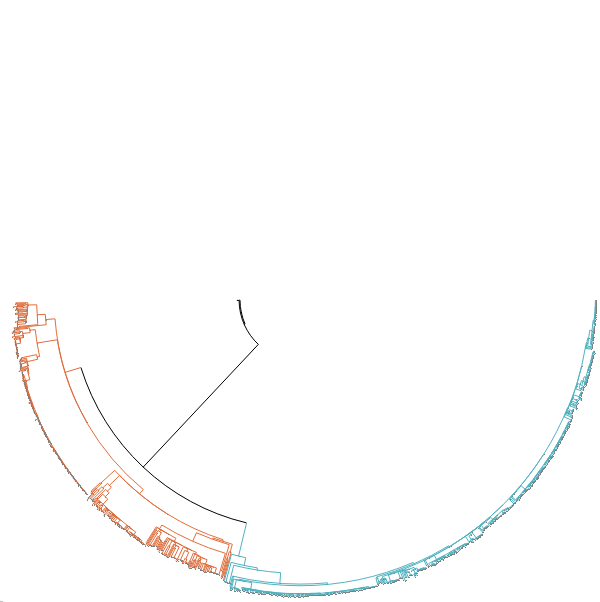

In [149]:
TGEN_Gubbins_Tree.render("%%inline", w = 600, tree_style = ts_IQ_circ)

### Visualize phylogeny in full-circular view w/ Lineage Colored Branches

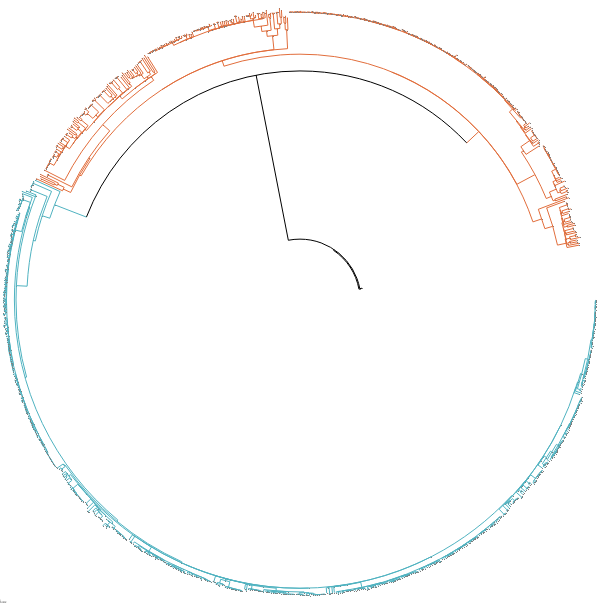

In [150]:
TGEN_Gubbins_Tree.render("%%inline", w = 600, tree_style = ts_IQ_FullCirc)